# Task: Covid-19 Data Analysis
### This notebook is used to understand the comprehension of Data Analysis techniques using Pandas library.

### Data Source: 
https://github.com/CSSEGISandData/COVID-19/tree/master/csse_covid_19_data/csse_covid_19_daily_reports

### File naming convention

MM-DD-YYYY.csv in UTC.

### Field description

- Province_State: China - province name; US/Canada/Australia/ - city name, state/province name; Others - name of the event (e.g., "Diamond Princess" cruise ship); other countries - blank.

- Country_Region: country/region name conforming to WHO (will be updated).

- Last_Update: MM/DD/YYYY HH:mm (24 hour format, in UTC).

- Confirmed: the number of confirmed cases. For Hubei Province: from Feb 13 (GMT +8), we report both clinically diagnosed and lab-confirmed cases. For lab-confirmed cases only (Before Feb 17), please refer to who_covid_19_situation_reports. For Italy, diagnosis standard might be changed since Feb 27 to "slow the growth of new case numbers." (Source)

- Deaths: the number of deaths.

- Recovered: the number of recovered cases.

### Question 1

#### Read the dataset

In [1]:
import pandas as pd
csv = pd.read_csv('https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_daily_reports/02-26-2021.csv')
csv

,FIPS,Admin2,Province_State,Country_Region,Last_Update,Lat,Long_,Confirmed,Deaths,Recovered,Active,Combined_Key,Incident_Rate,Case_Fatality_Ratio
0,NaN,NaN,NaN,Afghanistan,2021-02-27 05:22:28,33.93911,67.709953,55696,2442,49285,3969,Afghanistan,143.073140,4.384516
1,NaN,NaN,NaN,Albania,2021-02-27 05:22:28,41.15330,20.168300,105229,1756,68007,35466,Albania,3656.577941,1.668742
2,NaN,NaN,NaN,Algeria,2021-02-27 05:22:28,28.03390,1.659600,112805,2977,77842,31986,Algeria,257.245877,2.639067
3,NaN,NaN,NaN,Andorra,2021-02-27 05:22:28,42.50630,1.521800,10822,110,10394,318,Andorra,14006.341811,1.016448
4,NaN,NaN,NaN,Angola,2021-02-27 05:22:28,-11.20270,17.873900,20759,504,19307,948,Angola,63.162024,2.427863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4009,NaN,NaN,Unknown,Ukraine,2021-02-27 05:22:28,NaN,NaN,0,0,0,0,"Unknown, Ukraine",0.000000,0.000000
4010,NaN,NaN,NaN,Nauru,2021-02-27 05:22:28,-0.52280,166.931500,0,0,0,0,Nauru,0.000000,0.000000
4011,NaN,NaN,Niue,New Zealand,2021-02-27 05:22:28,-19.05440,-169.867200,0,0,0,0,"Niue, New Zealand",0.000000,0.000000
4012,NaN,NaN,NaN,Tuvalu,2021-02-27 05:22:28,-7.10950,177.649300,0,0,0,0,Tuvalu,0.000000,0.000000


#### Display the top 5 rows in the data

In [2]:
csv.head()

,FIPS,Admin2,Province_State,Country_Region,Last_Update,Lat,Long_,Confirmed,Deaths,Recovered,Active,Combined_Key,Incident_Rate,Case_Fatality_Ratio
0,NaN,NaN,NaN,Afghanistan,2021-02-27 05:22:28,33.93911,67.709953,55696,2442,49285,3969,Afghanistan,143.073140,4.384516
1,NaN,NaN,NaN,Albania,2021-02-27 05:22:28,41.15330,20.168300,105229,1756,68007,35466,Albania,3656.577941,1.668742
2,NaN,NaN,NaN,Algeria,2021-02-27 05:22:28,28.03390,1.659600,112805,2977,77842,31986,Algeria,257.245877,2.639067
3,NaN,NaN,NaN,Andorra,2021-02-27 05:22:28,42.50630,1.521800,10822,110,10394,318,Andorra,14006.341811,1.016448
4,NaN,NaN,NaN,Angola,2021-02-27 05:22:28,-11.20270,17.873900,20759,504,19307,948,Angola,63.162024,2.427863


#### Show the information of the dataset

In [3]:
csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4014 entries, 0 to 4013
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   FIPS                 3266 non-null   float64
 1   Admin2               3271 non-null   object 
 2   Province_State       3835 non-null   object 
 3   Country_Region       4014 non-null   object 
 4   Last_Update          4014 non-null   object 
 5   Lat                  3924 non-null   float64
 6   Long_                3924 non-null   float64
 7   Confirmed            4014 non-null   int64  
 8   Deaths               4014 non-null   int64  
 9   Recovered            4014 non-null   int64  
 10  Active               4014 non-null   int64  
 11  Combined_Key         4014 non-null   object 
 12  Incident_Rate        3924 non-null   float64
 13  Case_Fatality_Ratio  3968 non-null   float64
dtypes: float64(5), int64(4), object(5)
memory usage: 439.2+ KB


#### Show the sum of missing values of features in the dataset

In [4]:
csv.isnull().sum()

FIPS                   748
Admin2                 743
Province_State         179
Country_Region           0
Last_Update              0
Lat                     90
Long_                   90
Confirmed                0
Deaths                   0
Recovered                0
Active                   0
Combined_Key             0
Incident_Rate           90
Case_Fatality_Ratio     46
dtype: int64

### Question 2

#### Show the number of Confirmed cases by Country

In [5]:
country_confirmed = csv.groupby("Country_Region")["Confirmed"].sum().reset_index()

print(country_confirmed)

           Country_Region  Confirmed
0             Afghanistan      55696
1                 Albania     105229
2                 Algeria     112805
3                 Andorra      10822
4                  Angola      20759
..                    ...        ...
196    West Bank and Gaza     180848
197  Winter Olympics 2022          0
198                 Yemen       2267
199                Zambia      77639
200              Zimbabwe      36044

[201 rows x 2 columns]


#### Show the number of Deaths by Country

In [6]:
country_deaths = (
    csv.groupby("Country_Region")["Deaths"]
        .sum()
        .reset_index()
)

country_deaths

,Country_Region,Deaths
0,Afghanistan,2442
1,Albania,1756
2,Algeria,2977
3,Andorra,110
4,Angola,504
...,...,...
196,West Bank and Gaza,2019
197,Winter Olympics 2022,0
198,Yemen,627
199,Zambia,1066


#### Show the number of Recovered cases by Country

In [7]:
country_recovered = (
    csv.groupby("Country_Region")["Recovered"]
        .sum()
        .reset_index()
        .sort_values(by="Recovered", ascending=False)
)
country_recovered.index = range(0, len(country_recovered))
country_recovered

,Country_Region,Recovered
0,India,10763451
1,Brazil,9309568
2,Russia,3741058
3,Turkey,2556785
4,Italy,2387032
...,...,...
196,Palau,0
197,Kiribati,0
198,Winter Olympics 2022,0
199,Serbia,0


#### Show the number of Active Cases by Country

In [8]:
country_active = (
    csv.groupby("Country_Region")["Active"]
        .sum()
        .reset_index()
        .sort_values(by="Active", ascending=False)
)
country_active.index = range(0, len(country_active))
country_active

,Country_Region,Active
0,US,28092088
1,United Kingdom,4041088
2,France,3423705
3,Spain,2969035
4,Mexico,1892408
...,...,...
196,Summer Olympics 2020,0
197,Tuvalu,0
198,Nauru,0
199,Tonga,0


#### Show the latest number of Confirmed, Deaths, Recovered and Active cases Country-wise

In [9]:
latest_stats = (
    csv.groupby("Country_Region")[["Confirmed", "Deaths", "Recovered", "Active"]]
      .sum()
      .reset_index()
      .sort_values(by="Confirmed", ascending=False)
)
latest_stats.index = range(0, len(country_active))
latest_stats

,Country_Region,Confirmed,Deaths,Recovered,Active
0,US,28641814,509227,0,28092088
1,India,11079979,156938,10763451,159590
2,Brazil,10466308,253154,9309568,893325
3,Russia,4175757,83900,3741058,350799
4,United Kingdom,4175311,148048,11579,4041088
...,...,...,...,...,...
196,Summer Olympics 2020,0,0,0,0
197,Tuvalu,0,0,0,0
198,Winter Olympics 2022,0,0,0,0
199,Nauru,0,0,0,0


### Question 3

### Show the countries with no recovered cases

In [10]:
country_recovered = (
    csv.groupby("Country_Region")["Recovered"]
        .sum()
        .reset_index()
)
no_recovered = country_recovered[country_recovered["Recovered"] == 0]
no_recovered.index = range(0, len(no_recovered))
no_recovered

,Country_Region,Recovered
0,Antarctica,0
1,Belgium,0
2,Kiribati,0
3,"Korea, North",0
4,Nauru,0
5,Palau,0
6,Serbia,0
7,Summer Olympics 2020,0
8,Sweden,0
9,Tonga,0


#### Show the countries with no confirmed cases

In [11]:
country_confirmed = (
    csv.groupby("Country_Region")["Confirmed"]
        .sum()
        .reset_index()
)
no_confirmed = country_confirmed[country_confirmed["Confirmed"] == 0]
no_confirmed.index = range(0, len(no_confirmed))
no_confirmed

,Country_Region,Confirmed
0,Antarctica,0
1,Kiribati,0
2,"Korea, North",0
3,Nauru,0
4,Palau,0
5,Summer Olympics 2020,0
6,Tonga,0
7,Tuvalu,0
8,Winter Olympics 2022,0


#### Show the countries with no deaths

In [12]:
country_deaths = (
    csv.groupby("Country_Region")["Deaths"]
        .sum()
        .reset_index()
)
no_deaths = country_deaths[country_deaths["Deaths"] == 0]
no_deaths.index = range(0, len(no_deaths))
no_deaths

,Country_Region,Deaths
0,Antarctica,0
1,Cambodia,0
2,Dominica,0
3,Holy See,0
4,Kiribati,0
5,"Korea, North",0
6,Laos,0
7,Marshall Islands,0
8,Micronesia,0
9,Nauru,0


In [13]:
deaths_stats = (
    csv.groupby("Country_Region")[["Confirmed", "Deaths", "Recovered"]]
      .sum()
      .reset_index()
      .sort_values(by="Confirmed", ascending=False)
)
no_deaths_stats = deaths_stats[deaths_stats["Deaths"] == 0]
no_deaths_stats.index = range(0, len(no_deaths_stats))
no_deaths_stats

,Country_Region,Confirmed,Deaths,Recovered
0,Cambodia,767,0,477
1,Dominica,142,0,127
2,Timor-Leste,110,0,89
3,Laos,45,0,42
4,Saint Kitts and Nevis,41,0,40
5,Holy See,27,0,15
6,Solomon Islands,18,0,14
7,Marshall Islands,4,0,4
8,Samoa,3,0,2
9,Vanuatu,1,0,1


### Question 4

#### Show the Top 10 countries with Confirmed cases

In [14]:
confirmed_stats = (
    csv.groupby("Country_Region", as_index=False)
       .agg({
           "Last_Update": "max",      # take the latest timestamp
           "Confirmed": "sum",
           "Deaths": "sum",
           "Recovered": "sum"
       })
       .sort_values(by="Confirmed", ascending=False)
)

confirmed_stats.head(10).style.hide(axis="index")

Country_Region,Last_Update,Confirmed,Deaths,Recovered
US,2021-04-02 15:13:53,28641814,509227,0
India,2021-02-27 05:22:28,11079979,156938,10763451
Brazil,2021-02-27 05:22:28,10466308,253154,9309568
Russia,2021-02-27 05:22:28,4175757,83900,3741058
United Kingdom,2021-02-27 05:22:28,4175311,148048,11579
France,2021-02-27 05:22:28,3771626,86272,261649
Spain,2021-02-27 05:22:28,3188553,69142,150376
Italy,2021-02-27 05:22:28,2888923,97227,2387032
Turkey,2021-02-27 05:22:28,2683971,28432,2556785
Germany,2021-02-27 05:22:28,2426501,69519,2247173


#### Show the Top 10 Countries with Active cases

In [15]:
active_stats = (
    csv.groupby("Country_Region", as_index=False)
       .agg({
           "Last_Update": "max",
           "Confirmed": "sum",
           "Deaths": "sum",
           "Recovered": "sum",
           "Active":"sum"
       })
       .sort_values(by="Active", ascending=False)
)

active_stats.head(10).style.hide(axis="index")

Country_Region,Last_Update,Confirmed,Deaths,Recovered,Active
US,2021-04-02 15:13:53,28641814,509227,0,28092088
United Kingdom,2021-02-27 05:22:28,4175311,148048,11579,4041088
France,2021-02-27 05:22:28,3771626,86272,261649,3423705
Spain,2021-02-27 05:22:28,3188553,69142,150376,2969035
Mexico,2021-02-27 05:22:28,2076882,184474,1625328,1892408
Peru,2021-02-27 05:22:28,1316363,121120,1218409,1187793
Netherlands,2021-02-27 05:22:28,1093899,15626,14330,1063943
Brazil,2021-02-27 05:22:28,10466308,253154,9309568,893325
Belgium,2021-02-27 05:22:28,766654,22034,0,752635
Sweden,2021-02-27 05:22:28,657309,12826,0,644483


### Question 5

#### Plot Country-wise Total deaths, confirmed, recovered and active casaes where total deaths have exceeded 50,000

In [16]:
import matplotlib.pyplot as plt

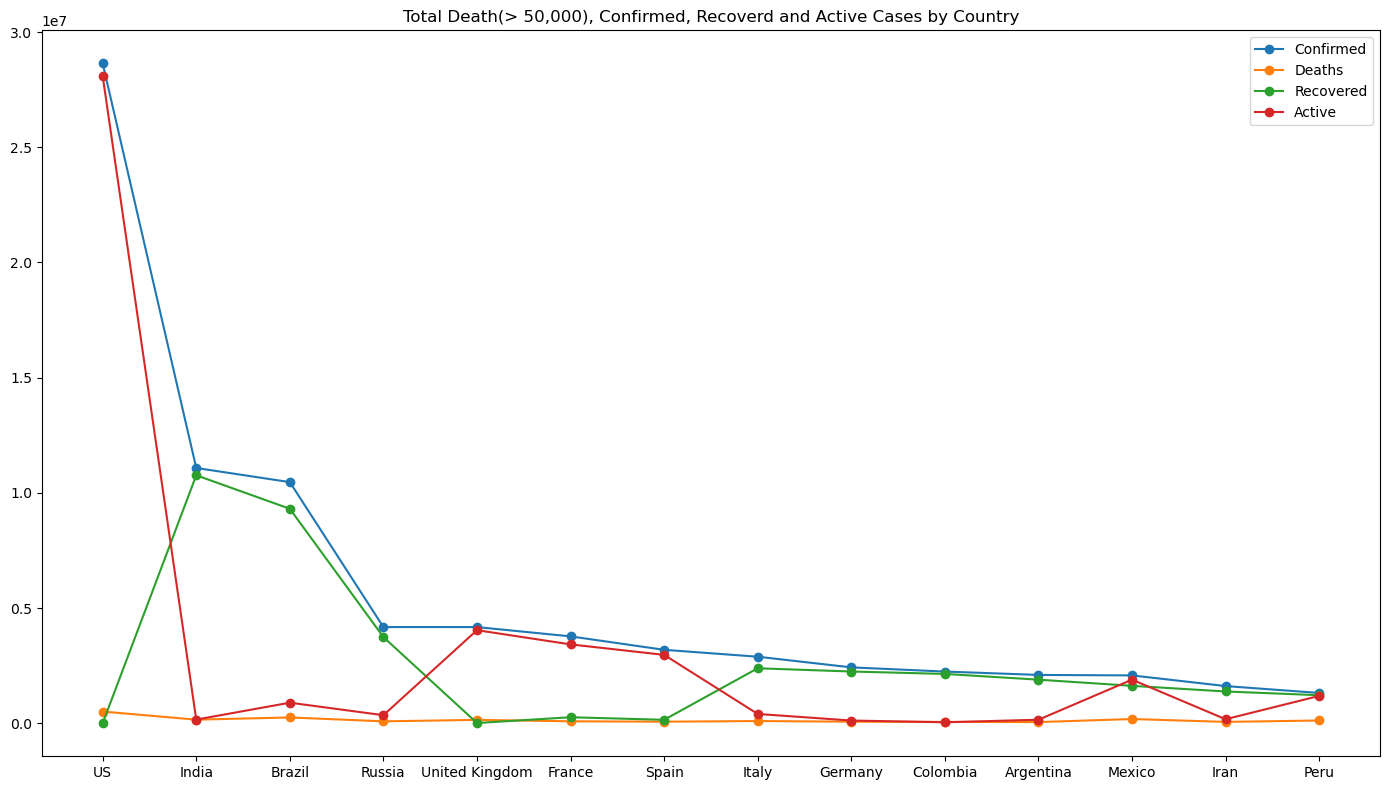

In [17]:
grouped = (
    csv.groupby("Country_Region")[["Confirmed", "Deaths", "Recovered", "Active"]]
      .sum()
      .reset_index()
      .sort_values(by="Confirmed", ascending=False)
)
deaths_mtft = grouped[grouped["Deaths"] > 50000]

plt.figure(figsize=(14, 8))

plt.plot(deaths_mtft["Country_Region"], deaths_mtft["Confirmed"], marker='o', label="Confirmed")
plt.plot(deaths_mtft["Country_Region"], deaths_mtft["Deaths"], marker='o', label="Deaths")
plt.plot(deaths_mtft["Country_Region"], deaths_mtft["Recovered"], marker='o', label="Recovered")
plt.plot(deaths_mtft["Country_Region"], deaths_mtft["Active"], marker='o', label="Active")

plt.title("Total Death(> 50,000), Confirmed, Recoverd and Active Cases by Country")
plt.legend()
plt.tight_layout()
plt.show()

### Question 6

### Plot Province/State wise Deaths in USA

In [18]:
import plotly.express as px

In [19]:
covid_data= pd.read_csv('https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_daily_reports/01-09-2021.csv')

In [20]:
covid_data.columns

Index(['FIPS', 'Admin2', 'Province_State', 'Country_Region', 'Last_Update',
       'Lat', 'Long_', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'Combined_Key', 'Incident_Rate', 'Case_Fatality_Ratio'],
      dtype='object')

In [21]:
usa_df = covid_data[covid_data["Country_Region"] == "US"]
state_deaths = (
    usa_df.groupby("Province_State")["Deaths"]
      .sum()
      .reset_index()
)

fig = px.bar(
    state_deaths,
    x="Province_State",
    y="Deaths",
    title="State wise deaths reported of COVID-19 in USA",
    text="Deaths"
)

fig.update_layout(
    xaxis_title="Province_State",
    yaxis_title="Deaths",
    width=1080,
    height=400  
)

fig.show()

### Question 7

### Plot Province/State Wise Active Cases in USA

In [22]:

state_active = (
    usa_df.groupby("Province_State")["Active"]
      .sum()
      .reset_index()
)

fig = px.bar(
    state_active,
    x="Province_State",
    y="Active",
    title="State wise active reported of COVID-19 in USA",
    text="Active"
)

fig.update_layout(
    xaxis_title="Province_State",
    yaxis_title="Active",
    width=1080,
    height=400  
)

fig.show()

### Question 8

### Plot Province/State Wise Confirmed cases in USA

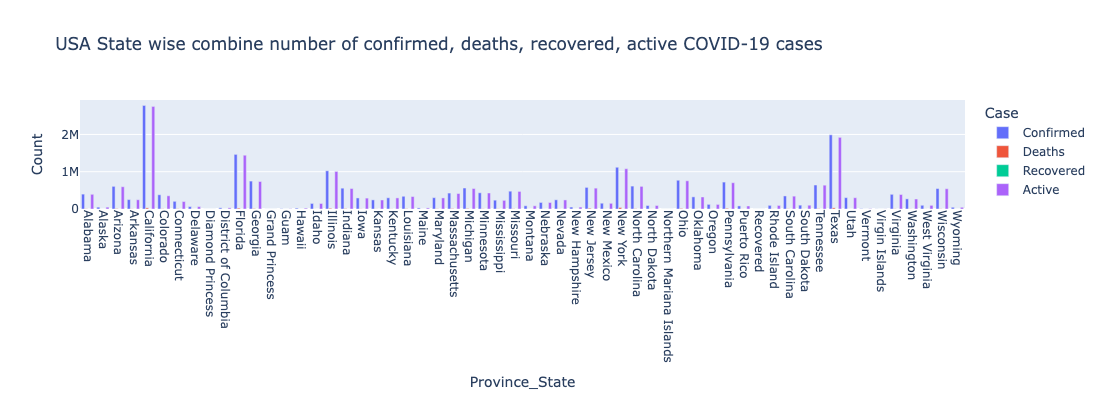

In [23]:
state_stats = (
    usa_df.groupby("Province_State")[["Confirmed", "Deaths", "Recovered", "Active"]]
          .sum()
          .reset_index()
)

# Melt the dataframe for Plotly Express
state_melted = state_stats.melt(
    id_vars="Province_State",
    value_vars=["Confirmed", "Deaths", "Recovered", "Active"],
    var_name="Case",
    value_name="Count"
)

# Create grouped bar chart
fig = px.bar(
    state_melted,
    x="Province_State",
    y="Count",
    color="Case",
    barmode="group",
    title="USA State wise combine number of confirmed, deaths, recovered, active COVID-19 cases"
)

fig.update_layout(
    xaxis_tickangle=90,
    width=1080,
    height=400 
)

fig.show()

### Question 9

### Plot Worldwide Confirmed Cases over time

In [24]:
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go

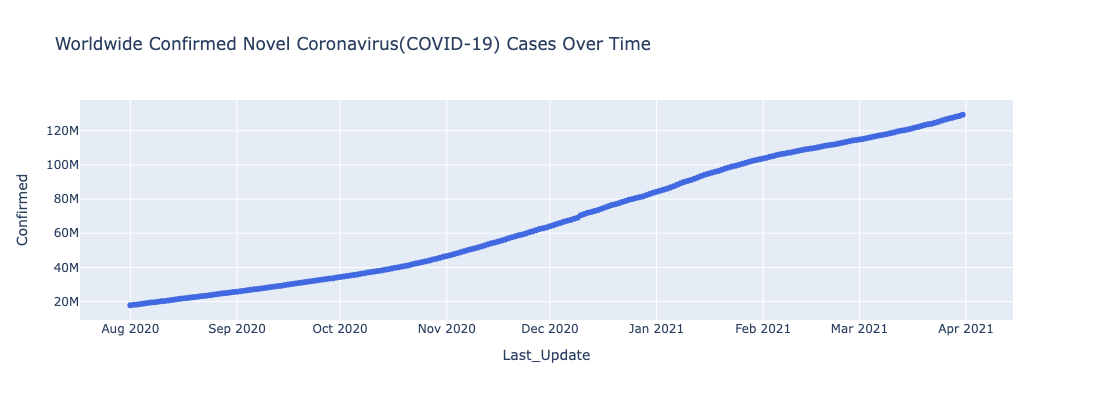

In [25]:
base_url = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_daily_reports/"

dates = pd.date_range("2020-08-01", "2021-03-31")

dfs = []
for d in dates:
    file = d.strftime("%m-%d-%Y") + ".csv"
    url = base_url + file
    try:
        df = pd.read_csv(url, usecols=["Confirmed", "Last_Update"])
        df["Report_Date"] = d
        dfs.append(df)
    except:
        pass  # skip missing files

all_data = pd.concat(dfs, ignore_index=True)
worldwide = (
    all_data.groupby("Report_Date")["Confirmed"]
            .sum()
            .reset_index()
            .sort_values("Report_Date")
)
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=worldwide["Report_Date"],
    y=worldwide["Confirmed"],
    mode="lines+markers",
    line=dict(color="royalblue", width=3),
    marker=dict(size=6),
    name="Worldwide Confirmed"
))

fig.update_layout(
    title="Worldwide Confirmed Novel Coronavirus(COVID-19) Cases Over Time",
    xaxis_title="Last_Update",
    yaxis_title="Confirmed",
    width=1080,
    height=400
)

pio.show(fig)